<a href="https://colab.research.google.com/github/fabriciosantana/mcdia/blob/main/13-dissertacao/notebooks/01-analisar-base-discursos-rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instituto Brasileiro de Ensino, Desenvolvimento e Pesquisa**

Programa de Pós-Graduação em Administração Pública  
**Mestrado Profissional em Administração Pública - Ciência de Dados e Inteligência Artificial**

**Pesquisa de Dissertação**  
**Aluno**: Fabricio Fernandes Santana  
**Orientador**: Prof. Dr. Marcelo Rodrigo de Souza Pita

## Análise da base de discursos da 56ª Legislatura do Senado Federal

Este notebook realiza uma auditoria reprodutível do corpus de discursos da 56ª Legislatura (01/02/2019 a 31/01/2023). Além da análise exploratória tradicional, investiga fatores que afetam uma solução de *Retrieval-Augmented Generation* (RAG): cobertura textual, qualidade dos documentos, duplicidade, distribuição de comprimentos, estimativa de tokens e chunks, qualidade dos metadados, desbalanceamentos e variação lexical no tempo.

A análise procura responder:
- qual é a cobertura e a integridade do corpus;
- como os discursos se distribuem no tempo e entre autores, partidos e UFs;
- quais propriedades textuais influenciam indexação, chunking e recuperação;
- onde há risco de redundância, ausência de contexto ou viés de representação; e
- quais decisões de preparação devem anteceder a construção do RAG.


### 1. Configurar notebook



Importe os pacotes Python e faça configurações globais. A lista de stopwords em português combina duas fontes públicas — NLTK e [Stopwords ISO](https://github.com/stopwords-iso/stopwords-iso) — e aplica a mesma normalização de caixa e acentos usada pelos vetorizadores. A lista do spaCy não é carregada porque exigiria uma dependência de maior consumo de memória para um ganho marginal de cobertura.

A união amplia a remoção de palavras funcionais nas visualizações de termos e bigramas, mas não é aplicada ao texto original nem ao corpus destinado ao RAG. Isso preserva integralmente o conteúdo que será indexado e evita que uma decisão exploratória elimine termos potencialmente relevantes para recuperação.

In [1]:
from __future__ import annotations

import hashlib
import math
import re
import unicodedata
from pathlib import Path

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from huggingface_hub import hf_hub_download
from scipy.spatial.distance import jensenshannon
from datasketch import MinHash, MinHashLSH
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import nltk
from nltk.corpus import stopwords
import stopwordsiso

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

def remover_acentos(valor: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFKD', valor) if not unicodedata.combining(c))

def normalizar_stopwords(palavras) -> set[str]:
    # Reproduz lowercase + strip_accents='unicode' usados pelos vetorizadores.
    return {remover_acentos(str(p).casefold()).strip() for p in palavras if str(p).strip()}

STOPWORDS_NLTK = normalizar_stopwords(stopwords.words('portuguese'))
STOPWORDS_ISO = normalizar_stopwords(stopwordsiso.stopwords('pt'))
STOPWORDS_PT = sorted(STOPWORDS_NLTK | STOPWORDS_ISO)

metricas_stopwords = pd.Series({
    'NLTK': len(STOPWORDS_NLTK),
    'Stopwords ISO': len(STOPWORDS_ISO),
    'União normalizada': len(STOPWORDS_PT),
}, name='quantidade')
display(metricas_stopwords.to_frame())
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'figure.figsize': (11, 5.5), 'figure.dpi': 120})
RANDOM_STATE = 42

,quantidade
NLTK,200
Stopwords ISO,537
União normalizada,538


## 2. Preparar base de dados


In [2]:
def mount_google_drive_and_return_path(arquivo: str) -> Path:
    from google.colab import drive # pyright: ignore[reportMissingImports]
    print("Montando Google Drive.")
    drive.mount('/content/drive')
    google_drive_data_dir = Path('/content/drive/MyDrive/Colab Notebooks/discursos-senado')
    google_drive_data_dir.mkdir(parents=True, exist_ok=True)

    target_file_path = google_drive_data_dir / arquivo
    print(f"Fazendo download do arquivo {HF_FILENAME} a partir do Hugging Face para Google Drive ({target_file_path})")

    caminho_local = Path(hf_hub_download(
        repo_id=HF_REPO_ID,
        repo_type='dataset',
        filename=HF_FILENAME,
        revision=HF_REVISION,
        local_dir=google_drive_data_dir # Changed to local_dir
    ))
    
    origem = f'Hugging Face ({HF_REPO_ID}@{HF_REVISION}) para Google Drive'
    sha256 = hashlib.sha256(caminho_local.read_bytes()).hexdigest()
    print(f'Origem: {origem}')
    print(f'Arquivo: {caminho_local}')
    print(f'SHA-256: {sha256}')
    assert sha256 == EXPECTED_SHA256, 'O arquivo não corresponde à versão documentada v1.1.1.'

    return caminho_local

A célula seguinte procura o arquivo local. Na ausência do arquivo, `hf_hub_download` faz download dos discursos que estão em um arquivo [Parquet publicado no Hugging Face](https://huggingface.co/datasets/fabriciosantana/discursos-senado-legislatura-56). O hash esperado documenta a versão analisada.

In [3]:
HF_REPO_ID = 'fabriciosantana/discursos-senado-legislatura-56'
HF_FILENAME = 'data/full/discursos_2019-02-01_2023-01-31.parquet'
HF_REVISION = 'v1.1.1'
EXPECTED_SHA256 = 'e09cfc4793e5394be440906320c7d3008cda5a52b90bbc85bf47446362406af1'
ARQUIVO = 'discursos_2019-02-01_2023-01-31.parquet'

DATA_FILE = Path.cwd().parent / 'dados' / ARQUIVO

if DATA_FILE.exists():
    caminho_local = DATA_FILE.resolve()
    origem = 'arquivo local'
elif "COLAB_RELEASE_TAG" in os.environ:
    caminho_local = mount_google_drive_and_return_path(ARQUIVO)
    origem = f'Hugging Face ({HF_REPO_ID}@{HF_REVISION}) para Google Drive'
else:
    caminho_local = Path(hf_hub_download(
        repo_id=HF_REPO_ID, repo_type='dataset', filename=HF_FILENAME, revision=HF_REVISION
    ))
    origem = f'Hugging Face ({HF_REPO_ID}@{HF_REVISION})'

sha256 = hashlib.sha256(caminho_local.read_bytes()).hexdigest()
print(f'Origem: {origem}')
print(f'Arquivo: {caminho_local}')
print(f'SHA-256: {sha256}')
assert sha256 == EXPECTED_SHA256, 'O arquivo não corresponde à versão documentada v1.1.1.'

Origem: arquivo local
Arquivo: /workspaces/mcdia/13-dissertacao/dados/discursos_2019-02-01_2023-01-31.parquet
SHA-256: e09cfc4793e5394be440906320c7d3008cda5a52b90bbc85bf47446362406af1


Verificar se dados foram carregados com sucesso.

In [4]:
df_raw = pd.read_parquet(caminho_local)
print(f'{len(df_raw):,} registros × {df_raw.shape[1]} colunas')
display(df_raw.head(3))

15,729 registros × 30 colunas


,id,CodigoPronunciamento,Casa,Data,Resumo,Indexacao,TextoIntegral,TextoIntegralTxt,UrlTextoBinario,TipoAutor,FuncaoAutor,NomeAutor,CodigoParlamentar,Partido,UF,TipoUsoPalavra.Codigo,TipoUsoPalavra.Sigla,TipoUsoPalavra.Descricao,TipoUsoPalavra.IndicadorAtivo,Publicacoes.Publicacao,Apartes.Aparteante,__janela_inicio,__janela_fim,CargoAutor,OrgaoAutor,PaisAutor,TextoDiscursoIntegral,ok,status,msg
0,451286,451286,Senado Federal,2019-02-27,"Comentários a respeito da concentração bancária no Brasil e de como ela afeta a cobrança de juros, das tarifas e dos...","COMENTARIO, CONCENTRAÇÃO, REDE BANCARIA, COBRANÇA, JUROS, TARIFAS, REGISTRO, AUSENCIA, COMPETIÇÃO, PREJUIZO, CONSUMI...",https://www25.senado.leg.br/web/atividade/pronunciamentos/-/p/texto/451286,https://legis.senado.leg.br/dadosabertos/discurso/texto-integral/451286,https://legis.senado.leg.br/dadosabertos/discurso/texto-binario/451286,Senador(a),SENADOR,Ciro Nogueira,739,PP,PI,4819,DIS,Discurso,Sim,"[{'DataPublicacao': '2019-02-28', 'FontePublicacao': 'Diário do Senado Federal', 'PaginaFinal': '118', 'PaginaInicia...",None,2019-02-01,2019-02-28,None,None,None,SENADO FEDERAL SF -\nSECRETARIA-GERAL DA MESA\nSECRETARIA DE REGISTRO E REDAÇÃO PARLAMENTAR - SERERP\nCOORDENAÇÃO DE...,True,200,
1,451285,451285,Senado Federal,2019-02-27,"Registro do impacto da reforma da previdência social na Lei nº 13.146, de 2015, que dispõe sobre o Estatuto da Pesso...","REGISTRO, REFORMA, PREVIDENCIA SOCIAL, ALTERAÇÃO, ESTATUTO, PESSOA DEFICIENTE, REGULAMENTAÇÃO, AVALIAÇÃO, DEFICIENCI...",https://www25.senado.leg.br/web/atividade/pronunciamentos/-/p/texto/451285,https://legis.senado.leg.br/dadosabertos/discurso/texto-integral/451285,https://legis.senado.leg.br/dadosabertos/discurso/texto-binario/451285,Senador(a),SENADOR,Paulo Paim,825,PT,RS,4819,DIS,Discurso,Sim,"[{'DataPublicacao': '2019-02-28', 'FontePublicacao': 'Diário do Senado Federal', 'PaginaFinal': '116', 'PaginaInicia...",None,2019-02-01,2019-02-28,None,None,None,SENADO FEDERAL SF -\nSECRETARIA-GERAL DA MESA\nSECRETARIA DE REGISTRO E REDAÇÃO PARLAMENTAR - SERERP\nCOORDENAÇÃO DE...,True,200,
2,451205,451205,Senado Federal,2019-02-27,"Comentários a respeito da catástrofe ocorrida em Brumadinho (MG) e satisfação com a aprovação, pela Comissão de Cons...","COMENTARIO, DESASTRE, ROMPIMENTO, BARRAGEM, BRUMADINHO (MG), ESTADO DE MINAS GERAIS (MG), REGISTRO, APRESENTAÇÃO, PR...",https://www25.senado.leg.br/web/atividade/pronunciamentos/-/p/texto/451205,https://legis.senado.leg.br/dadosabertos/discurso/texto-integral/451205,https://legis.senado.leg.br/dadosabertos/discurso/texto-binario/451205,Senador(a),SENADOR,Wellington Fagundes,1173,PR,MT,4819,DIS,Discurso,Sim,"[{'DataPublicacao': '2019-02-28', 'FontePublicacao': 'Diário do Senado Federal', 'PaginaFinal': '99', 'PaginaInicial...",None,2019-02-01,2019-02-28,None,None,None,"O SR. WELLINGTON FAGUNDES (Bloco Parlamentar Vanguarda/PR - MT. Para discursar.) – Senador Marcos Rogério, que bom p...",True,200,


## 3. Estrutura, integridade e completude

Primeiro auditamos esquema, tipos, valores ausentes, chaves e intervalo temporal. Essa etapa separa problemas estruturais de ausências esperadas na fonte.

In [5]:
def contar_unicos(serie: pd.Series) -> int:
    # Colunas aninhadas podem conter arrays/listas, que não são diretamente hashable.
    if serie.dtype == 'object':
        return serie.dropna().map(repr).nunique()
    return serie.nunique(dropna=True)

visao_colunas = (
    pd.DataFrame({
        'tipo': df_raw.dtypes.astype(str),
        'preenchidos': df_raw.notna().sum(),
        'ausentes': df_raw.isna().sum(),
        'unicos': pd.Series({c: contar_unicos(df_raw[c]) for c in df_raw.columns}),
    })
    .assign(ausentes_pct=lambda x: (100 * x['ausentes'] / len(df_raw)).round(2))
    .sort_values(['ausentes_pct', 'unicos'], ascending=[False, True])
)
display(visao_colunas)

,tipo,preenchidos,ausentes,unicos,ausentes_pct
PaisAutor,object,97,15632,6,99.38
OrgaoAutor,object,811,14918,558,94.84
Apartes.Aparteante,object,868,14861,350,94.48
CargoAutor,object,904,14825,459,94.25
UF,object,13655,2074,27,13.19
Partido,object,13655,2074,32,13.19
CodigoParlamentar,object,13655,2074,233,13.19
Publicacoes.Publicacao,object,14995,734,13651,4.67
Resumo,object,15672,57,10726,0.36
Indexacao,object,15694,35,10812,0.22


In [6]:
df = df_raw.copy()
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
for coluna in ['Resumo', 'Indexacao', 'TextoDiscursoIntegral', 'NomeAutor', 'Partido', 'UF']:
    df[coluna] = df[coluna].fillna('').astype(str).str.strip()

integridade = pd.Series({
    'registros': len(df),
    'colunas': df.shape[1],
    'códigos únicos': df['CodigoPronunciamento'].nunique(dropna=True),
    'códigos duplicados': df['CodigoPronunciamento'].duplicated(keep=False).sum(),
    'datas inválidas': df['Data'].isna().sum(),
    'data mínima': df['Data'].min(),
    'data máxima': df['Data'].max(),
    'autores': df.loc[df['NomeAutor'].ne(''), 'NomeAutor'].nunique(),
    'partidos': df.loc[df['Partido'].ne(''), 'Partido'].nunique(),
    'UFs': df.loc[df['UF'].ne(''), 'UF'].nunique(),
}, name='valor')
display(integridade.to_frame())

,valor
registros,15729
colunas,30
códigos únicos,15729
códigos duplicados,0
datas inválidas,0
data mínima,2019-02-01 00:00:00
data máxima,2023-01-10 00:00:00
autores,1787
partidos,32
UFs,27


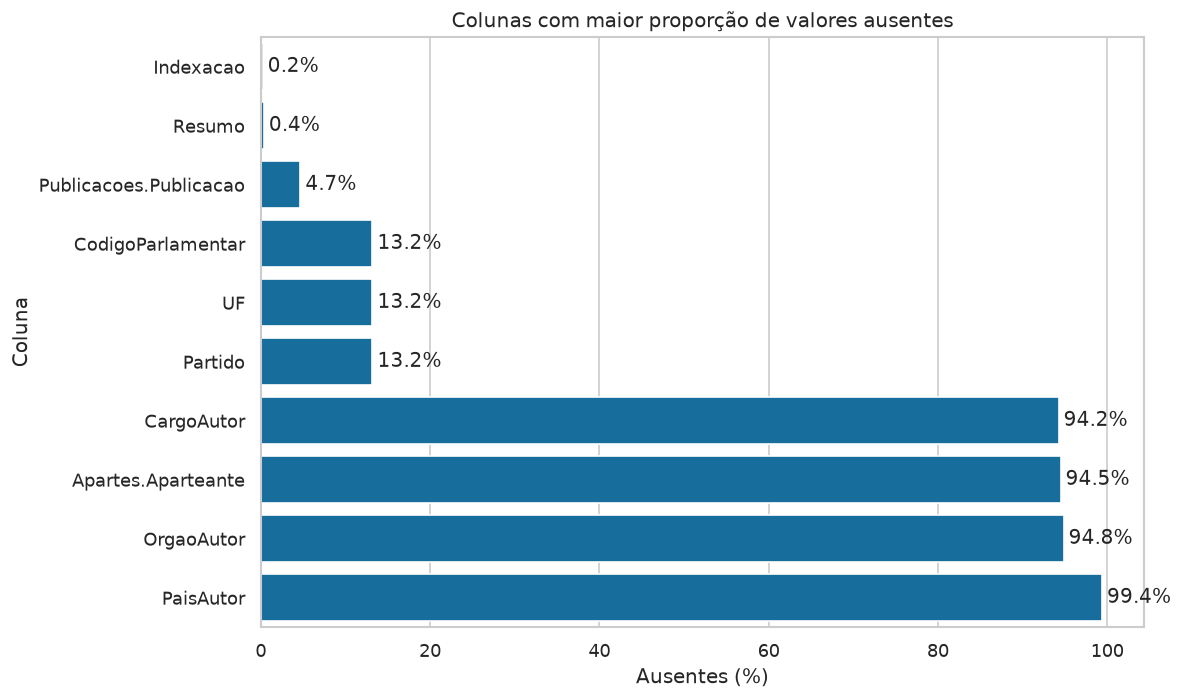

In [7]:
faltantes_plot = visao_colunas.query('ausentes > 0').sort_values('ausentes_pct').tail(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=faltantes_plot.reset_index(), x='ausentes_pct', y='index', ax=ax)
ax.set(title='Colunas com maior proporção de valores ausentes', xlabel='Ausentes (%)', ylabel='Coluna')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()

### 3.1 Cobertura dos textos

Para o RAG, não basta contar linhas. É necessário distinguir texto integral, resumo substituto e registro sem conteúdo recuperável. A coluna `fonte_documento` conserva essa proveniência para filtros e avaliações posteriores.

In [8]:
tem_integral = df['TextoDiscursoIntegral'].ne('')
tem_resumo = df['Resumo'].ne('')
df['fonte_documento'] = np.select(
    [tem_integral, ~tem_integral & tem_resumo],
    ['texto_integral', 'resumo_fallback'],
    default='indisponível',
)
df['documento_rag'] = np.where(tem_integral, df['TextoDiscursoIntegral'], df['Resumo'])

cobertura = df['fonte_documento'].value_counts().rename_axis('fonte').to_frame('registros')
cobertura['percentual'] = (100 * cobertura['registros'] / len(df)).round(2)
display(cobertura)
display(pd.crosstab(df['status'], df['fonte_documento'], margins=True))

,registros,percentual
fonte,,
texto_integral,15039,95.61
resumo_fallback,687,4.37
indisponível,3,0.02


fonte_documento,indisponível,resumo_fallback,texto_integral,All
status,,,,
200,0,0,15039,15039
404,3,687,0,690
All,3,687,15039,15729


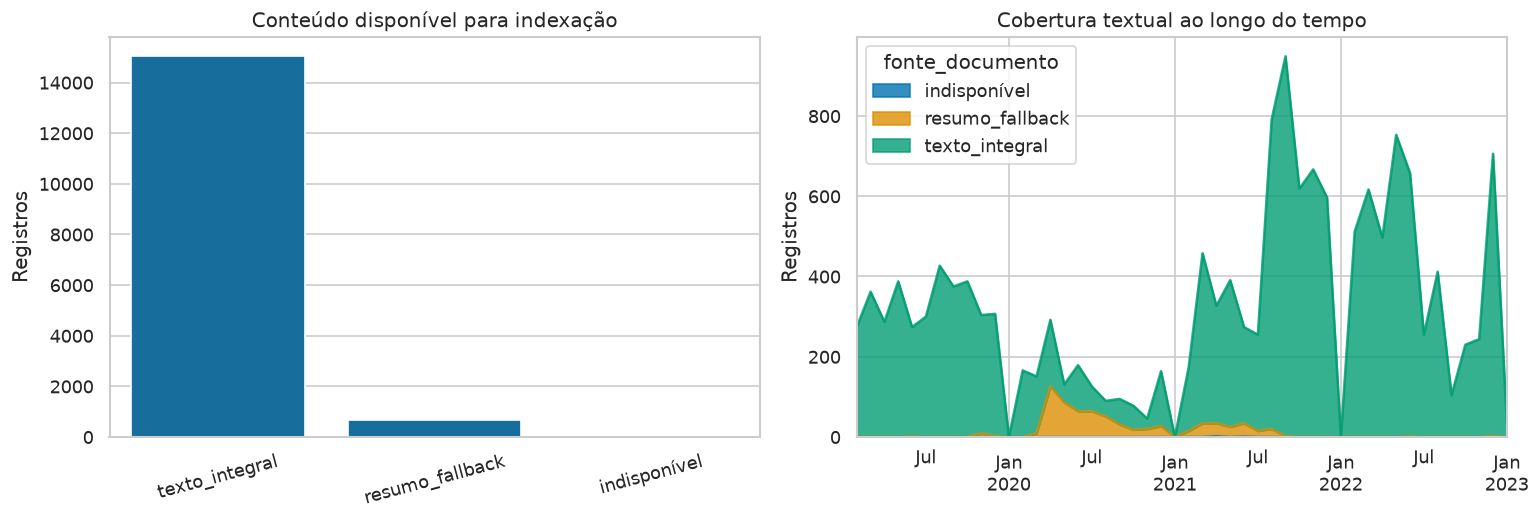

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df, x='fonte_documento', order=['texto_integral', 'resumo_fallback', 'indisponível'], ax=axes[0])
axes[0].set(title='Conteúdo disponível para indexação', xlabel='', ylabel='Registros')
axes[0].tick_params(axis='x', rotation=15)
calendario_cobertura = pd.date_range('2019-02-01', '2023-01-01', freq='MS')
status_mensal = (df.assign(mes=df['Data'].dt.to_period('M').dt.to_timestamp())
                  .groupby(['mes', 'fonte_documento']).size().unstack(fill_value=0)
                  .reindex(calendario_cobertura, fill_value=0))
status_mensal.plot.area(ax=axes[1], alpha=.8)
axes[1].set(title='Cobertura textual ao longo do tempo', xlabel='', ylabel='Registros')
plt.tight_layout()

## 4. Distribuições temporal, institucional e geográfica

Essas distribuições revelam cobertura, sazonalidade e grupos dominantes. Em RAG, maior volume implica maior probabilidade de recuperação; portanto, frequência documental não deve ser confundida com relevância substantiva.

,discursos
count,48.00
mean,327.69
std,228.91
min,0.00
25%,160.75
50%,289.50
75%,434.75
max,949.00


,mes,discursos
11,2020-01,0
23,2021-01,0
35,2022-01,0


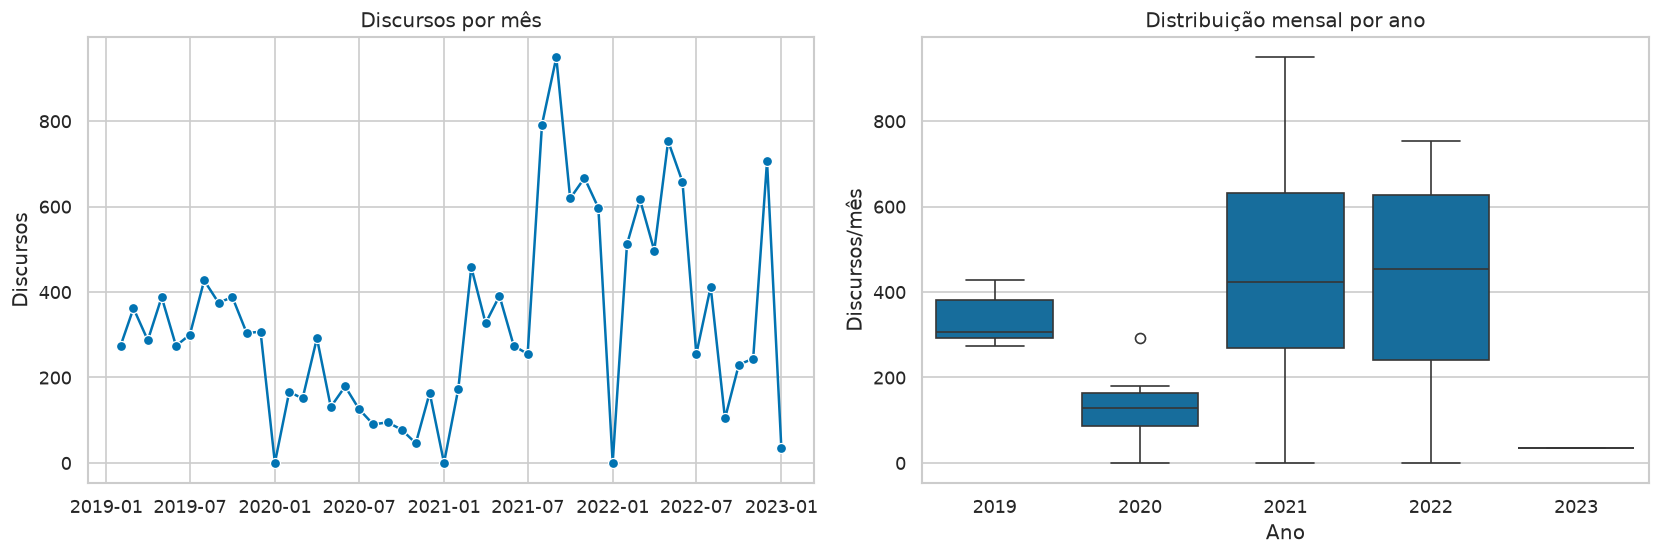

In [10]:
df['ano'] = df['Data'].dt.year.astype('Int64')
df['mes'] = df['Data'].dt.to_period('M').dt.to_timestamp()
df['dia_semana'] = df['Data'].dt.day_name()
# Reindexar pelo calendário completo torna explícitos os meses sem discursos.
calendario_mensal = pd.date_range('2019-02-01', '2023-01-01', freq='MS')
mensal = (df.groupby('mes').size().rename('discursos')
          .reindex(calendario_mensal, fill_value=0)
          .rename_axis('mes').reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=mensal, x='mes', y='discursos', marker='o', ax=axes[0])
axes[0].set(title='Discursos por mês', xlabel='', ylabel='Discursos')
sns.boxplot(data=mensal.assign(ano=mensal['mes'].dt.year), x='ano', y='discursos', ax=axes[1])
axes[1].set(title='Distribuição mensal por ano', xlabel='Ano', ylabel='Discursos/mês')
plt.tight_layout()
display(mensal['discursos'].describe().round(2).to_frame())
display(mensal.loc[mensal['discursos'].eq(0)].assign(mes=lambda x: x['mes'].dt.strftime('%Y-%m')))

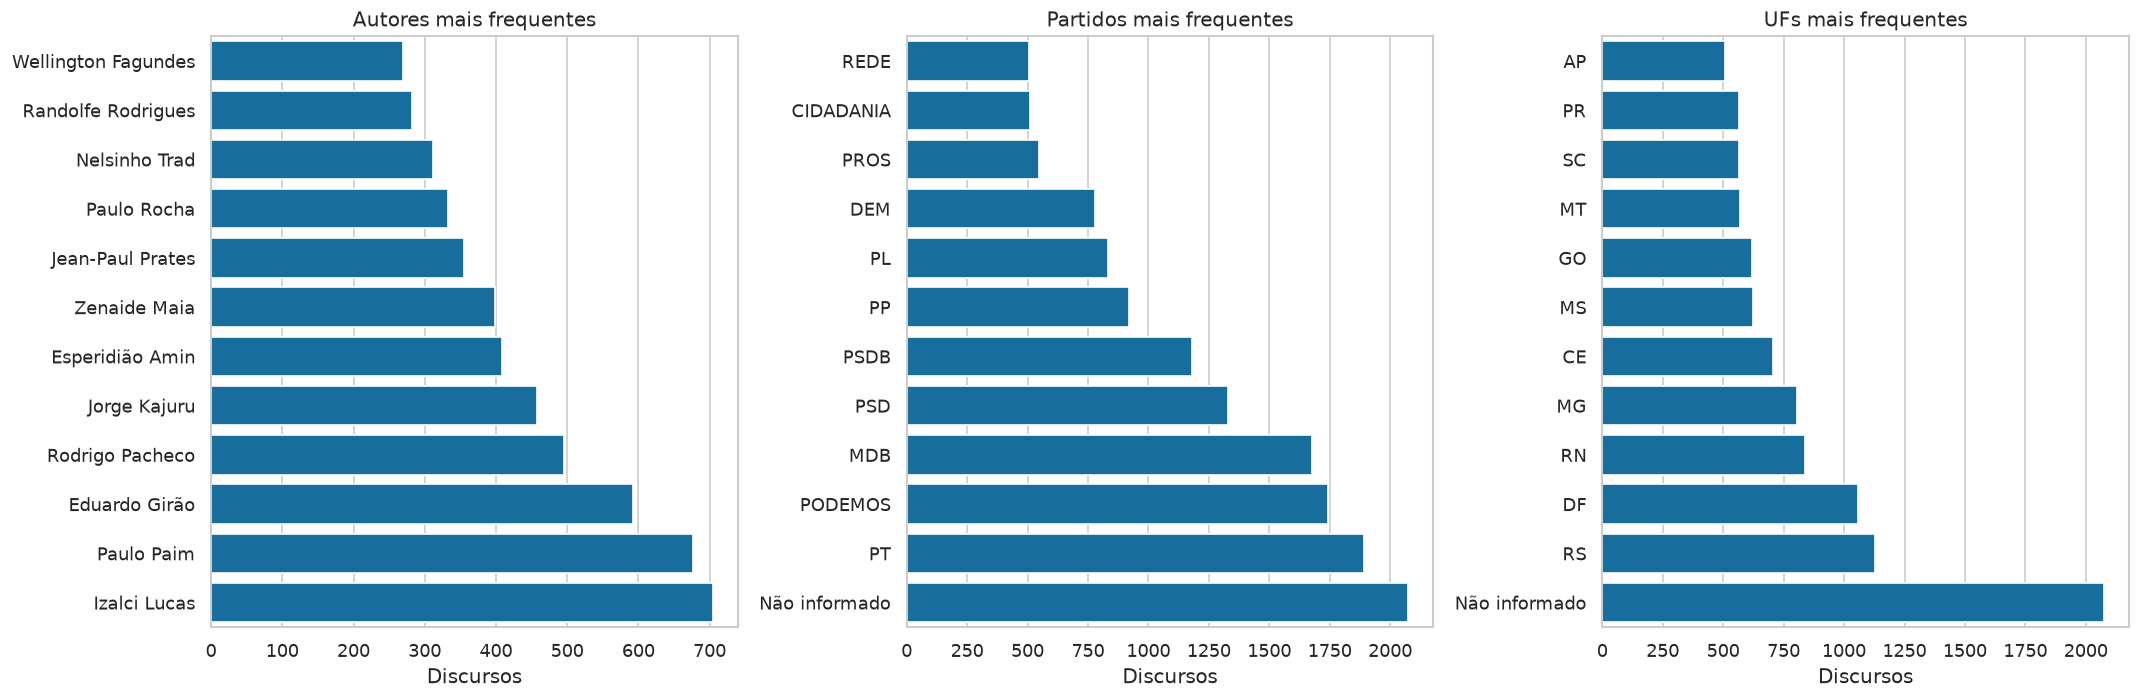

In [11]:
def ranking(coluna: str, n: int = 15) -> pd.DataFrame:
    serie = df[coluna].replace('', 'Não informado').value_counts().head(n)
    return serie.rename('discursos').rename_axis(coluna).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, coluna, titulo in zip(
    axes, ['NomeAutor', 'Partido', 'UF'],
    ['Autores mais frequentes', 'Partidos mais frequentes', 'UFs mais frequentes']
):
    dados = ranking(coluna, 12).sort_values('discursos')
    sns.barplot(data=dados, x='discursos', y=coluna, ax=ax)
    ax.set(title=titulo, xlabel='Discursos', ylabel='')
plt.tight_layout()

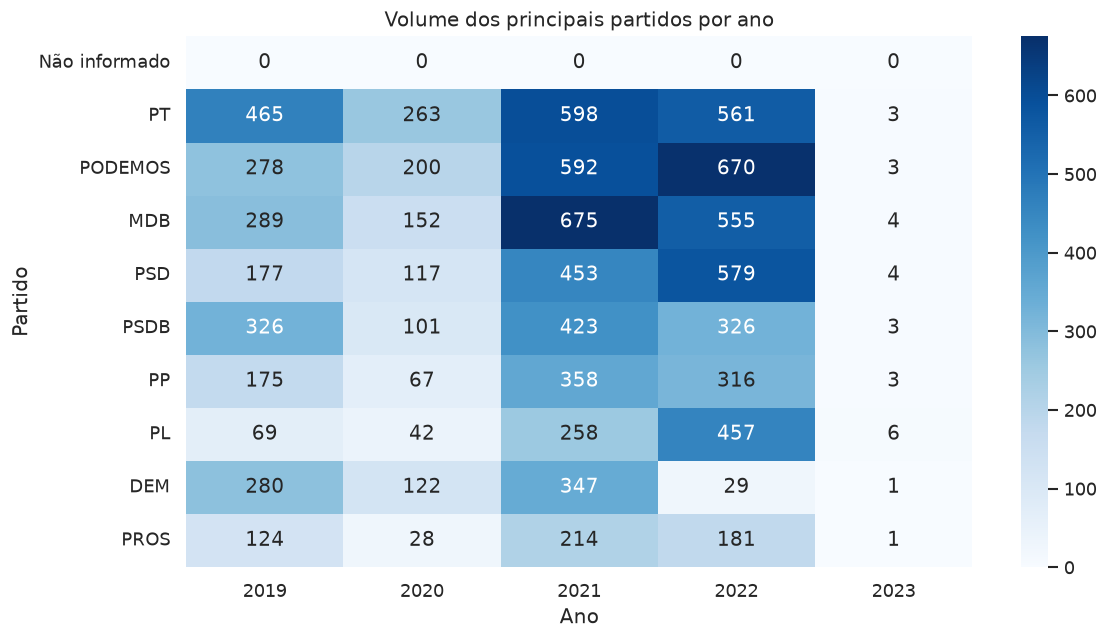

In [12]:
partidos_top = ranking('Partido', 10)['Partido'].tolist()
matriz_partido_ano = pd.crosstab(df['Partido'], df['ano']).reindex(partidos_top).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(matriz_partido_ano, annot=True, fmt='.0f', cmap='Blues', ax=ax)
ax.set(title='Volume dos principais partidos por ano', xlabel='Ano', ylabel='Partido')
plt.tight_layout()

## 5. Qualidade textual e adequação para indexação

Medidas de palavras, caracteres e linhas identificam documentos muito curtos, cauda longa e possíveis artefatos. A estimativa de tokens é deliberadamente aproximada; o cálculo definitivo deverá usar o tokenizador do modelo de embeddings escolhido.

In [13]:
texto = df['documento_rag'].fillna('').astype(str)
df['n_caracteres'] = texto.str.len()
df['n_palavras'] = texto.str.count(r'\S+')
df['n_linhas'] = texto.str.count(r'\n') + texto.ne('').astype(int)
df['tokens_estimados'] = np.ceil(df['n_caracteres'] / 4).astype(int)
df['razao_caracteres_palavra'] = np.where(df['n_palavras'] > 0, df['n_caracteres'] / df['n_palavras'], np.nan)

quantis = df.loc[df['n_palavras'] > 0, ['n_caracteres', 'n_palavras', 'n_linhas', 'tokens_estimados']].quantile(
    [0, .01, .05, .25, .5, .75, .9, .95, .99, 1]
).round(1)
display(quantis)

,n_caracteres,n_palavras,n_linhas,tokens_estimados
0.00,38.0,6.0,1.0,10.0
0.01,123.0,19.0,1.0,31.0
0.05,193.0,30.0,1.0,49.0
0.25,1203.0,195.0,5.0,301.0
0.50,2843.0,464.0,9.0,711.0
0.75,5595.0,912.8,18.0,1399.0
0.90,10510.0,1711.5,33.0,2628.0
0.95,14567.2,2398.8,46.0,3642.0
0.99,24760.8,4103.2,85.0,6190.2
1.00,106610.0,17602.0,464.0,26653.0


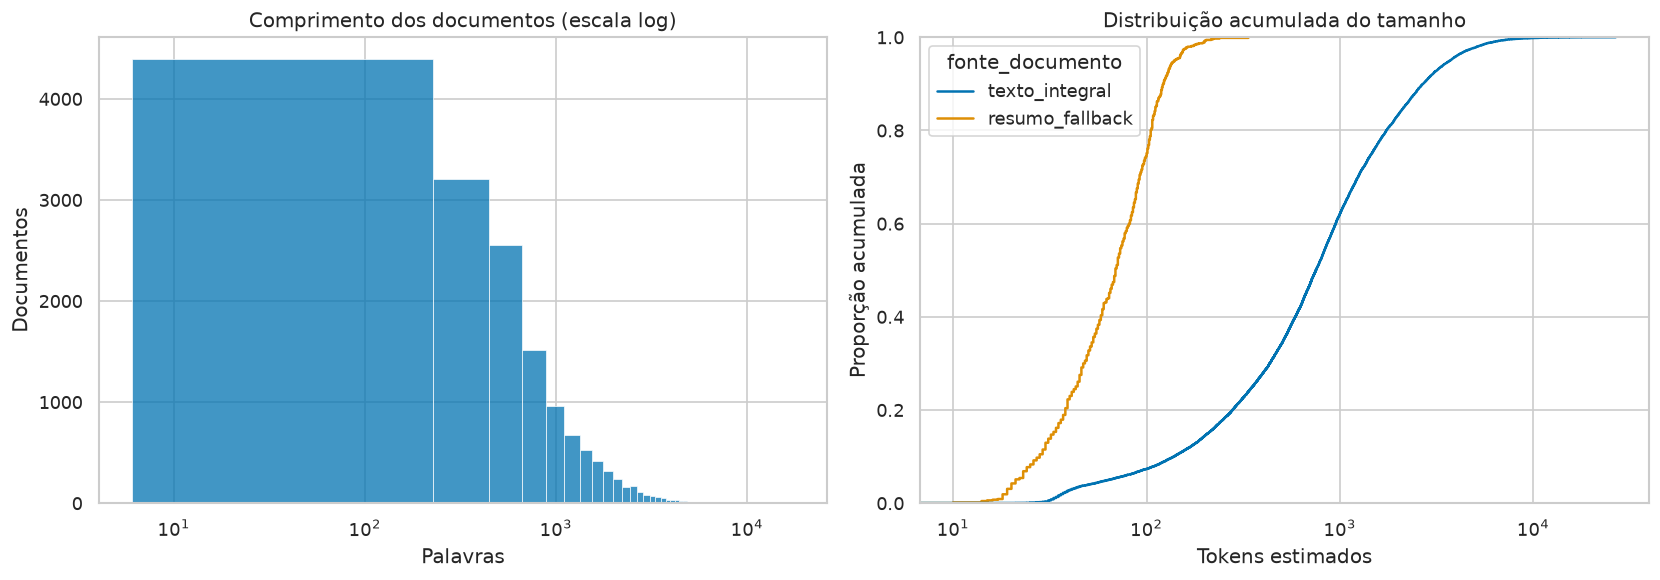

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df.loc[df['n_palavras'] > 0, 'n_palavras'], bins=80, ax=axes[0])
axes[0].set(xscale='log', title='Comprimento dos documentos (escala log)', xlabel='Palavras', ylabel='Documentos')
sns.ecdfplot(data=df.query('n_palavras > 0'), x='tokens_estimados', hue='fonte_documento', ax=axes[1])
axes[1].set(xscale='log', title='Distribuição acumulada do tamanho', xlabel='Tokens estimados', ylabel='Proporção acumulada')
plt.tight_layout()

In [15]:
padroes = {
    'vazio': texto.eq(''),
    'menos_de_50_palavras': df['n_palavras'].between(1, 49),
    'mais_de_10_mil_palavras': df['n_palavras'].gt(10_000),
    'possui_html': texto.str.contains(r'<[^>]+>', regex=True, na=False),
    'possui_url': texto.str.contains(r'https?://|www\.', regex=True, case=False, na=False),
    'espaços_repetidos': texto.str.contains(r' {3,}', regex=True, na=False),
    'caractere_substituição': texto.str.contains('�', regex=False, na=False),
}
qualidade_textual = pd.DataFrame({
    nome: {'registros': mascara.sum(), 'percentual': 100 * mascara.mean()}
    for nome, mascara in padroes.items()
}).T.round(2).sort_values('registros', ascending=False)
display(qualidade_textual)

,registros,percentual
menos_de_50_palavras,1291.0,8.21
possui_url,44.0,0.28
mais_de_10_mil_palavras,7.0,0.04
vazio,3.0,0.02
possui_html,1.0,0.01
espaços_repetidos,0.0,0.00
caractere_substituição,0.0,0.00


### 5.1 Duplicidade exata e conteúdo repetido

Documentos idênticos podem gerar chunks redundantes, dominar os vizinhos mais próximos e reduzir a diversidade dos resultados. A normalização abaixo é conservadora e serve apenas para diagnosticar duplicidade exata após diferenças triviais de caixa e espaços.

In [16]:
def normalizar_para_hash(valor: str) -> str:
    valor = unicodedata.normalize('NFKC', valor).casefold()
    return re.sub(r'\s+', ' ', valor).strip()

normalizado = texto.map(normalizar_para_hash)
df['hash_texto'] = normalizado.map(lambda x: hashlib.sha256(x.encode('utf-8')).hexdigest() if x else '')
duplicados_texto = df.loc[df['hash_texto'].ne('') & df['hash_texto'].duplicated(keep=False)]
grupos_duplicados = duplicados_texto.groupby('hash_texto').size().sort_values(ascending=False)

duplicidade = pd.Series({
    'registros em grupos duplicados': len(duplicados_texto),
    'grupos de texto duplicado': len(grupos_duplicados),
    'cópias excedentes': int((grupos_duplicados - 1).sum()),
    'percentual de cópias excedentes': round(100 * (grupos_duplicados - 1).sum() / len(df), 2),
})
display(duplicidade.to_frame('valor'))
display(grupos_duplicados.head(10).rename('ocorrências').to_frame())

,valor
registros em grupos duplicados,49.00
grupos de texto duplicado,21.00
cópias excedentes,28.00
percentual de cópias excedentes,0.18


,ocorrências
hash_texto,
71a47557e3614a2bcfa3d5f8292c40bc15c6e75119489e9d8b99b8457f522230,6
549b105d50df1f92b1100a3c976d1102cff5e6964d49ebbcdcadf46aaaced883,3
5b2aad2b3780bf16dbf2719818dbd1314050b473d057d37c4f574b12488acd14,3
2804cc7b834be272ef782cdb69660352edb4c3b00a86bab5331e74e99481b8ab,3
0547c09a82ca49cd8c7464837ce495c9e8e973249150e090d5e7f6c8510b0e60,2
487e4ee671ecbfa432dd03a81d65930d36d7c625cc1b1ffd80cfdd4b9ee9bf70,2
43f777017ac048ee02f3cced38f2de1ed79024824f7c31e2a992e25cda2cbba5,2
254fff1da3f211b76d24f66afa4b574d05c7443376137a80b1598f782e7082a2,2
51ea690876320d59dc1fb0bb10c22096d1404c23f09457de1859de8350c3957e,2


### 5.2 Duplicidade aproximada em amostra controlada

A duplicidade exata não captura pequenas edições, republicações ou trechos quase idênticos. Para complementar a auditoria sem calcular todas as combinações do corpus, selecionamos uma amostra reprodutível de até 800 documentos com pelo menos 50 palavras. Aplicamos três técnicas complementares: MinHash para geração eficiente de candidatos, Jaccard exato sobre shingles de cinco palavras e vizinho mais próximo por similaridade TF-IDF de caracteres. O tamanho da amostra e o limite de 15 mil atributos controlam o consumo de memória, inclusive no Google Colab. Os resultados são diagnósticos; qualquer remoção exige inspeção do contexto legislativo.

In [17]:
candidatos_aprox = df.loc[df['fonte_documento'].ne('indisponível') & df['n_palavras'].ge(50)].copy()
amostra_aprox = candidatos_aprox.sample(n=min(800, len(candidatos_aprox)), random_state=RANDOM_STATE)

def shingles_palavras(valor: str, n: int = 5) -> set[str]:
    tokens = re.findall(r'(?u)\b\w{2,}\b', normalizar_para_hash(valor))
    return {' '.join(tokens[i:i+n]) for i in range(max(0, len(tokens) - n + 1))}

shingles = {idx: shingles_palavras(txt) for idx, txt in amostra_aprox['documento_rag'].items()}
lsh = MinHashLSH(threshold=0.75, num_perm=128)
minhashes = {}
for idx, conjunto in shingles.items():
    assinatura = MinHash(num_perm=128, seed=RANDOM_STATE)
    for shingle in conjunto:
        assinatura.update(shingle.encode('utf-8'))
    minhashes[idx] = assinatura
    lsh.insert(str(idx), assinatura)

pares_candidatos = set()
for idx, assinatura in minhashes.items():
    for outro in lsh.query(assinatura):
        outro = int(outro)
        if idx != outro:
            pares_candidatos.add(tuple(sorted((idx, outro))))

linhas_jaccard = []
for idx_a, idx_b in pares_candidatos:
    a, b = shingles[idx_a], shingles[idx_b]
    jaccard = len(a & b) / len(a | b) if (a | b) else 0.0
    linhas_jaccard.append({
        'indice_a': idx_a, 'indice_b': idx_b, 'jaccard_5_shingles': jaccard,
        'codigo_a': df.at[idx_a, 'CodigoPronunciamento'], 'codigo_b': df.at[idx_b, 'CodigoPronunciamento'],
        'mesmo_hash_exato': df.at[idx_a, 'hash_texto'] == df.at[idx_b, 'hash_texto'],
    })
pares_jaccard = pd.DataFrame(linhas_jaccard, columns=[
    'indice_a', 'indice_b', 'jaccard_5_shingles', 'codigo_a', 'codigo_b', 'mesmo_hash_exato'
]).sort_values('jaccard_5_shingles', ascending=False)

tfidf_aprox = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=15_000, dtype=np.float32)
matriz_aprox = tfidf_aprox.fit_transform(amostra_aprox['documento_rag'])
vizinhos = NearestNeighbors(n_neighbors=2, metric='cosine').fit(matriz_aprox)
distancias, indices_vizinhos = vizinhos.kneighbors(matriz_aprox)
indices_originais = amostra_aprox.index.to_numpy()
pares_tfidf = pd.DataFrame({
    'indice_a': indices_originais,
    'indice_b': indices_originais[indices_vizinhos[:, 1]],
    'similaridade_tfidf': 1 - distancias[:, 1],
}).assign(
    codigo_a=lambda x: x['indice_a'].map(df['CodigoPronunciamento']),
    codigo_b=lambda x: x['indice_b'].map(df['CodigoPronunciamento']),
).sort_values('similaridade_tfidf', ascending=False)
pares_tfidf['jaccard_5_shingles'] = [
    len(shingles[a] & shingles[b]) / len(shingles[a] | shingles[b]) if (shingles[a] | shingles[b]) else 0.0
    for a, b in zip(pares_tfidf['indice_a'], pares_tfidf['indice_b'])
]

resumo_aproximada = pd.Series({
    'documentos na amostra': len(amostra_aprox),
    'pares candidatos por MinHash': len(pares_candidatos),
    'pares com Jaccard >= 0,80': int((pares_jaccard['jaccard_5_shingles'] >= .80).sum()),
    'documentos cujo vizinho TF-IDF >= 0,90': int((pares_tfidf['similaridade_tfidf'] >= .90).sum()),
})
display(resumo_aproximada.to_frame('valor'))
display(pares_jaccard.head(15).round(3))
display(pares_tfidf.head(15).round(3))

,valor
documentos na amostra,800
pares candidatos por MinHash,0
"pares com Jaccard >= 0,80",0
"documentos cujo vizinho TF-IDF >= 0,90",2


,indice_a,indice_b,jaccard_5_shingles,codigo_a,codigo_b,mesmo_hash_exato


,indice_a,indice_b,similaridade_tfidf,codigo_a,codigo_b,jaccard_5_shingles
184,15473,8914,0.979,494698,485305,0.000
178,8914,15473,0.979,485305,494698,0.000
72,2344,2347,0.830,458108,458102,0.001
385,2347,2344,0.830,458102,458108,0.001
40,169,907,0.817,450736,452273,0.003
170,907,169,0.817,452273,450736,0.003
574,1992,169,0.806,456690,450736,0.000
796,4721,3271,0.799,469208,461435,0.044
795,3271,4721,0.799,461435,469208,0.044
465,2078,3670,0.796,456587,462597,0.000


### 5.3 Inspeção qualitativa dos casos de qualidade

As tabelas seguintes tornam auditáveis as contagens anteriores. Os textos são truncados apenas para exibição; os documentos originais permanecem inalterados.

In [18]:
def tabela_inspecao(base: pd.DataFrame, n: int | None = 10) -> pd.DataFrame:
    colunas = ['CodigoPronunciamento', 'Data', 'NomeAutor', 'Partido', 'UF', 'fonte_documento', 'n_palavras', 'documento_rag']
    resultado = base.loc[:, colunas].copy()
    resultado['trecho'] = resultado.pop('documento_rag').str.replace(r'\s+', ' ', regex=True).str.slice(0, 240)
    return resultado.head(n) if n is not None else resultado

display(Markdown('#### Dez menores documentos não vazios'))
display(tabela_inspecao(df.query('n_palavras > 0').sort_values('n_palavras'), 10))
display(Markdown('#### Dez maiores documentos'))
display(tabela_inspecao(df.sort_values('n_palavras', ascending=False), 10))

duplicados_exemplo = (duplicados_texto.assign(ocorrencias=lambda x: x.groupby('hash_texto')['hash_texto'].transform('size'))
                      .sort_values(['ocorrencias', 'hash_texto'], ascending=[False, True]))
display(Markdown('#### Exemplos dos grupos de duplicidade exata'))
display(tabela_inspecao(duplicados_exemplo, 15))
display(Markdown('#### Registros que usam resumo como fallback'))
display(tabela_inspecao(df.query("fonte_documento == 'resumo_fallback'").sort_values('Data'), 10))
display(Markdown('#### Registros que contêm URL ou marcação HTML'))
display(tabela_inspecao(df.loc[padroes['possui_url'] | padroes['possui_html']].sort_values('Data'), 10))
display(Markdown('#### Registros sem texto integral nem resumo'))
display(tabela_inspecao(df.query("fonte_documento == 'indisponível'"), None))

#### Dez menores documentos não vazios

,CodigoPronunciamento,Data,NomeAutor,Partido,UF,fonte_documento,n_palavras,trecho
4424,467057,2020-05-02,Confúcio Moura,MDB,RO,resumo_fallback,6,Comentário sobre o Dia do Trabalhador.
4897,470451,2020-09-09,Confúcio Moura,MDB,RO,resumo_fallback,8,Considerações sobre a comemoração do Dia da Independência
6942,481266,2021-07-13,Eduardo Girão,PODEMOS,CE,resumo_fallback,8,Comentário sobre as divergências políticas existentes no País.
5144,473009,2020-12-16,Eduardo Girão,PODEMOS,CE,resumo_fallback,8,Balanço do mandato parlamentar nos últimos dois anos.
4346,467055,2020-05-19,Eduardo Girão,PODEMOS,CE,resumo_fallback,9,Reflexão sobre a situação da saúde pública no Brasil.
3565,462799,2019-12-09,HUGO FLOREZ,,,texto_integral,9,O SR. HUGO FLOREZ – (Discurso em língua estrangeira.)
4557,468427,2020-06-16,Confúcio Moura,MDB,RO,resumo_fallback,9,Defesa da reformulação e da simplificação da Constituição Federal.
3201,462703,2019-11-19,Darci de Matos,PSD,SC,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3198,462707,2019-11-19,CARLOS ALEXANDRE DA COSTA,,,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3202,462702,2019-11-19,Carmen Zanotto,CIDADANIA,SC,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.


#### Dez maiores documentos

,CodigoPronunciamento,Data,NomeAutor,Partido,UF,fonte_documento,n_palavras,trecho
15112,495137,2022-12-21,Jean-Paul Prates,PT,RN,texto_integral,17602,"O SR. JEAN PAUL PRATES (Bloco Parlamentar da Resistência Democrática/PT - RN. Para discursar.) – Obrigado, Sr. Presi..."
15647,494807,2022-12-07,Fernando Bezerra Coelho,MDB,PE,texto_integral,14201,"O SR. FERNANDO BEZERRA COELHO (Bloco Parlamentar Unidos pelo Brasil/MDB - PE. Para discursar.) – Sr. Presidente, Srs..."
15447,494548,2022-12-14,Simone Tebet,MDB,MS,texto_integral,11793,"A SRA. SIMONE TEBET (Bloco Parlamentar Unidos pelo Brasil/MDB - MS. Para discursar.) – Obrigada, Sr. Presidente Vene..."
15316,494790,2022-12-15,Alvaro Dias,PODEMOS,PR,texto_integral,11136,"O SR. ALVARO DIAS (Bloco Parlamentar Juntos pelo Brasil/PODEMOS - PR. Para discursar.) – Obrigado, Presidente Rodrig..."
15448,494547,2022-12-14,Nilda Gondim,MDB,PB,texto_integral,11055,"A SRA. NILDA GONDIM (Bloco Parlamentar Unidos pelo Brasil/MDB - PB. Para discursar.) – Obrigada, Sr. Presidente. Boa..."
7312,482552,2021-08-20,PAULO GUEDES,,,texto_integral,10598,"O SR. PAULO GUEDES (Para exposição de convidado.) – Amigos, bom dia a todos. Foi muito bom participar. Eu acho que, ..."
15081,495184,2022-12-21,Paulo Rocha,PT,PA,texto_integral,10204,O SR. PAULO ROCHA (Bloco Parlamentar da Resistência Democrática/PT - PA. Para discursar.) – Eu vou falar agora da mi...
15161,495051,2022-12-20,Kátia Abreu,PP,TO,texto_integral,9743,"A SRA. KÁTIA ABREU (Bloco Parlamentar Unidos pelo Brasil/PP - TO. Para discursar.) – Obrigada, Sr. Presidente. Eu ap..."
1485,454577,2019-06-07,Eduardo Girão,PODEMOS,CE,texto_integral,9244,O SR. EDUARDO GIRÃO (Bloco Parlamentar PSDB/PODE/PSL/PODE - CE. Para discursar.) – Muito obrigado. Senador Capitão S...
13482,491727,2022-06-13,Fernando Bezerra Coelho,MDB,PE,texto_integral,9217,O SR. FERNANDO BEZERRA COELHO (Bloco Parlamentar Unidos pelo Brasil/MDB - PE. Para proferir parecer.) – Sr. Presiden...


#### Exemplos dos grupos de duplicidade exata

...

,CodigoPronunciamento,Data,NomeAutor,Partido,UF,fonte_documento,n_palavras,trecho
1472,455207,2019-06-11,Marcelo Castro,MDB,PI,resumo_fallback,15,"Considerações sobre a importância para o País da aprovação do PLN nº 4, de 2019."
3375,461050,2019-11-01,Confúcio Moura,MDB,RO,resumo_fallback,22,"Defesa de uma reforma tributária, em tramitação no Congresso Nacional, que simplifique os impostos e priorize o cres..."
3197,462708,2019-11-19,Jorginho Mello,PL,SC,resumo_fallback,12,Encerramento da Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3198,462707,2019-11-19,CARLOS ALEXANDRE DA COSTA,,,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3199,462705,2019-11-19,ALCIDE ANDRADE,,,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3200,462704,2019-11-19,JOSÉ CARLOS MAGALHÃES PINTO,,,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3201,462703,2019-11-19,Darci de Matos,PSD,SC,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3202,462702,2019-11-19,Carmen Zanotto,CIDADANIA,SC,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3203,462701,2019-11-19,CARLOS DO CARMO ANDRADE MELLES,,,resumo_fallback,10,Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.
3204,462700,2019-11-19,Jorginho Mello,PL,SC,resumo_fallback,12,Abertura de Sessão Solene destinada a comemorar a Semana Global de Empreendedorismo.


#### Registros que contêm URL ou marcação HTML

,CodigoPronunciamento,Data,NomeAutor,Partido,UF,fonte_documento,n_palavras,trecho
114,450933,2019-02-15,Jorge Kajuru,PSB,GO,texto_integral,4442,O SR. JORGE KAJURU (Bloco Parlamentar Senado Independente/PSB - GO. Para discursar.) – Meu querido exemplo do Distri...
1287,453219,2019-05-06,GILDENORA BATISTA DANTAS MILHOMEM,,,texto_integral,1918,"A SRA. GILDENORA BATISTA DANTAS MILHOMEM – Exmo. Senador Izalci Lucas, a quem nós agradecemos por ser o Presidente e..."
1192,453342,2019-05-09,Paulo Paim,PT,RS,texto_integral,1935,"O SR. PAULO PAIM (Bloco Parlamentar da Resistência Democrática/PT - RS. Pela Liderança.) – Senador Girão, venho à tr..."
1097,453668,2019-05-17,Izalci Lucas,PSDB,DF,texto_integral,2012,"O SR. IZALCI LUCAS (Bloco Parlamentar PSDB/PODE/PSL/PSDB - DF. Para discursar.) – Sr. Presidente, Sras. e Srs. Parla..."
923,454170,2019-05-31,Izalci Lucas,PSDB,DF,texto_integral,1145,SENADO FEDERAL SF - SECRETARIA-GERAL DA MESA SECRETARIA DE REGISTRO E REDAÇÃO PARLAMENTAR - SERERP COORDENAÇÃO DE RE...
1319,455396,2019-06-28,Izalci Lucas,PSDB,DF,texto_integral,1485,"O SR. IZALCI LUCAS (Bloco Parlamentar PSDB/PODE/PSL/PSDB - DF. Para discursar.) – Obrigado, Senador Paim. Sr. Presid..."
1884,455227,2019-07-01,Lasier Martins,PODEMOS,RS,texto_integral,1222,O SR. PRESIDENTE (Lasier Martins. Bloco Parlamentar PSDB/PODE/PSL/PODEMOS - RS) – Declaro aberta esta sessão. Sob a ...
1587,455922,2019-07-17,Izalci Lucas,PSDB,DF,texto_integral,1740,"O SR. IZALCI LUCAS (Bloco Parlamentar PSDB/PSL/PSDB - DF. Para discursar.) – Sr. Presidente, Sras. e Srs. Senadores,..."
1917,456856,2019-08-29,Paulo Paim,PT,RS,texto_integral,3183,O SR. PAULO PAIM (Bloco Parlamentar da Resistência Democrática/PT - RS. Para discursar.) – Sr. Presidente Senador St...
3381,463380,2019-12-18,Izalci Lucas,PSDB,DF,texto_integral,2464,"O SR. IZALCI LUCAS (Bloco Parlamentar PSDB/PSL/PSDB - DF. Para discursar.) – Sr. Presidente, Sras. Senadoras e Srs. ..."


#### Registros sem texto integral nem resumo

,CodigoPronunciamento,Data,NomeAutor,Partido,UF,fonte_documento,n_palavras,trecho
5933,486753,2021-04-19,Eduardo Gomes,MDB,TO,indisponível,0,
5934,486686,2021-04-19,Eduardo Gomes,MDB,TO,indisponível,0,
6820,486869,2021-06-01,Wolney Queiroz,PDT,PE,indisponível,0,


## 6. Vocabulário e variação lexical

A frequência de termos ajuda a encontrar ruído, fórmulas regimentais e vocabulário dominante. Não substitui análise temática. O ajuste limita-se aos documentos integrais e usa `min_df` para evitar que erros raros dominem o vocabulário.

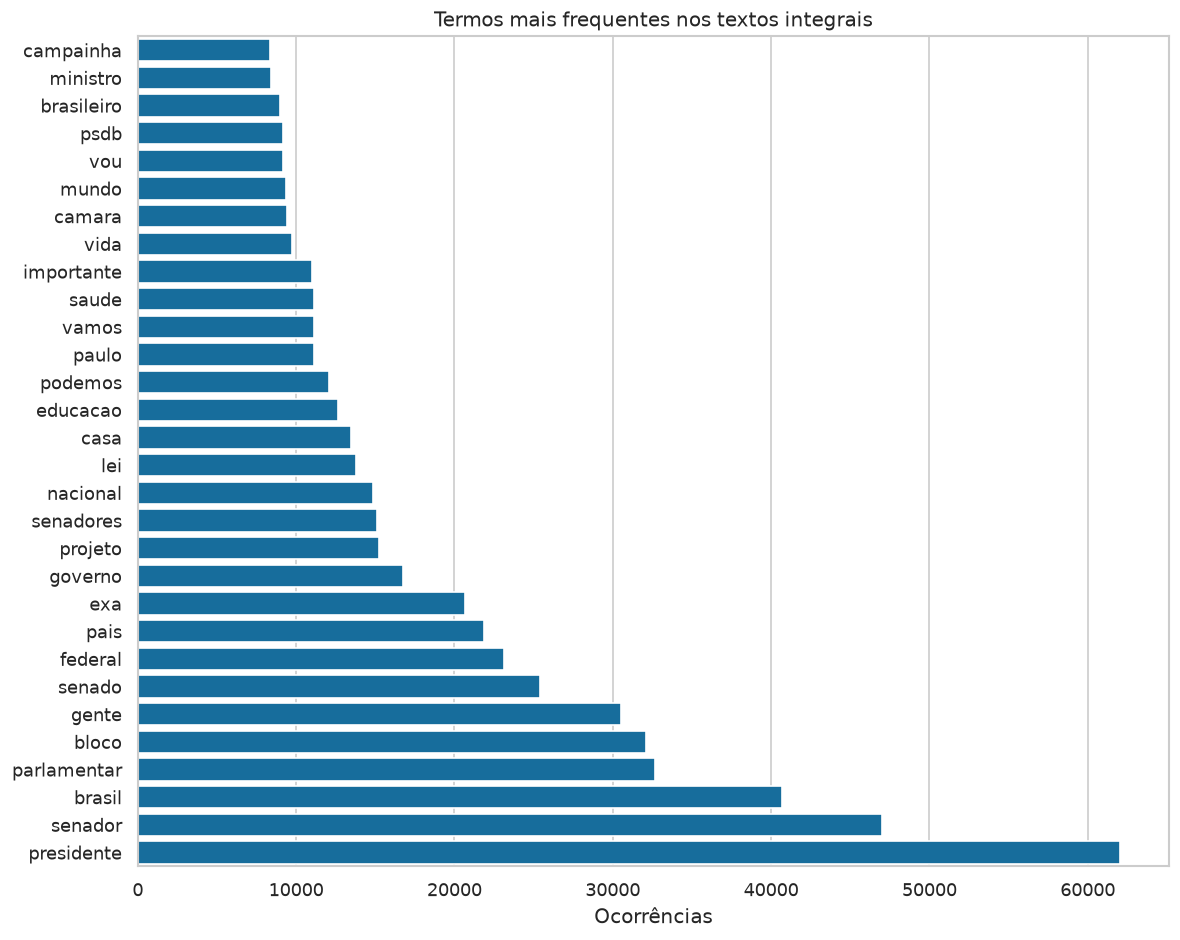

In [19]:
corpus_integral = df.loc[df['fonte_documento'].eq('texto_integral'), 'documento_rag']
vectorizer = CountVectorizer(
    lowercase=True, strip_accents='unicode', stop_words=sorted(STOPWORDS_PT), # Using NLTK stopwords
    min_df=10, max_df=.98, token_pattern=r'(?u)\b[a-zA-ZÀ-ÿ]{3,}\b',
)
X = vectorizer.fit_transform(corpus_integral)
frequencias = np.asarray(X.sum(axis=0)).ravel()
termos = pd.DataFrame({'termo': vectorizer.get_feature_names_out(), 'frequencia': frequencias})
top_termos = termos.nlargest(30, 'frequencia').sort_values('frequencia')

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_termos, x='frequencia', y='termo', ax=ax)
ax.set(title='Termos mais frequentes nos textos integrais', xlabel='Ocorrências', ylabel='')
plt.tight_layout()

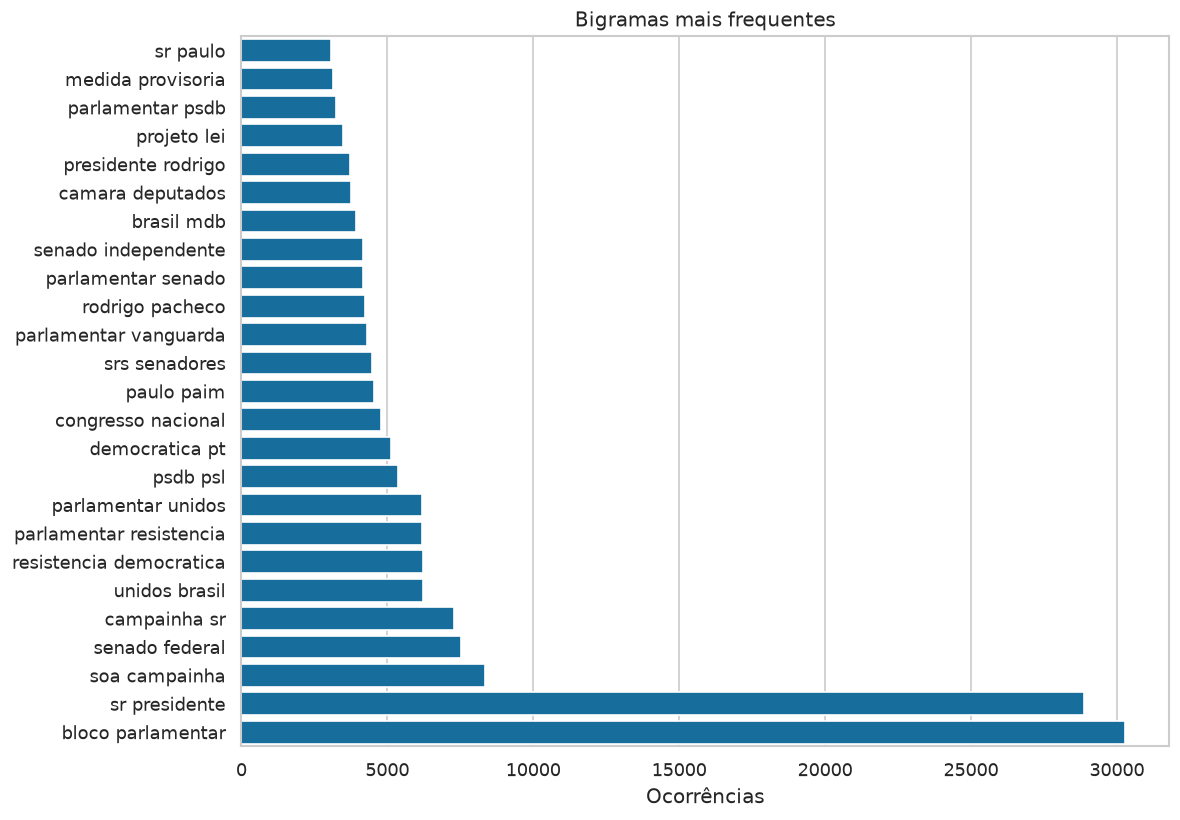

In [20]:
vetor_bi = CountVectorizer(
    lowercase=True, strip_accents='unicode', stop_words=sorted(STOPWORDS_PT),
    ngram_range=(2, 2), min_df=20, max_features=5_000,
)
bigramas = vetor_bi.fit_transform(corpus_integral)
top_bi = pd.DataFrame({
    'bigrama': vetor_bi.get_feature_names_out(),
    'frequencia': np.asarray(bigramas.sum(axis=0)).ravel(),
}).nlargest(25, 'frequencia').sort_values('frequencia')
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_bi, x='frequencia', y='bigrama', ax=ax)
ax.set(title='Bigramas mais frequentes', xlabel='Ocorrências', ylabel='')
plt.tight_layout()

### 6.1 Mudança lexical entre anos

A distância de Jensen–Shannon compara distribuições de termos e varia de 0 (iguais) a 1 com logaritmo de base 2 (muito distintas). Mudanças elevadas sugerem que consultas, avaliações e amostras do RAG devem cobrir diferentes períodos.

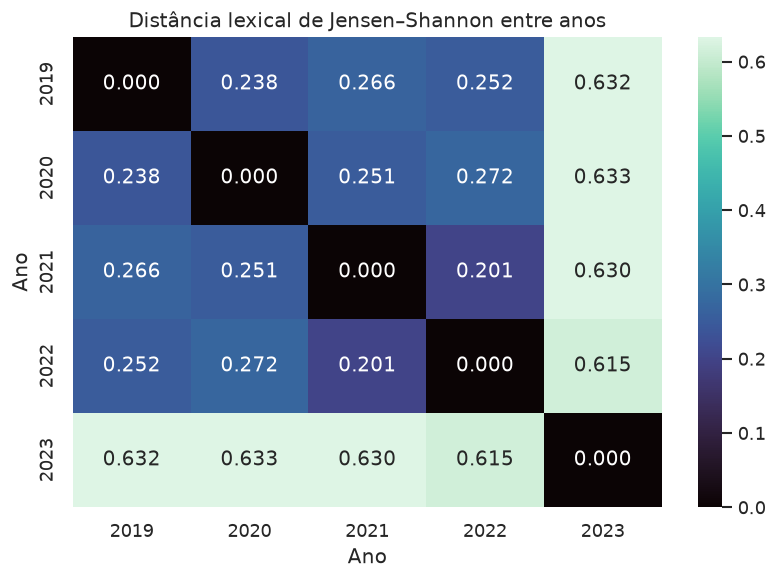

In [21]:
indices_integrais = df.index[df['fonte_documento'].eq('texto_integral')]
anos_integral = df.loc[indices_integrais, 'ano'].astype(str).to_numpy()
anos_validos = sorted(pd.unique(anos_integral))
distribuicoes = {}
for ano in anos_validos:
    contagens = np.asarray(X[anos_integral == ano].sum(axis=0)).ravel().astype(float) + 1e-12
    distribuicoes[ano] = contagens / contagens.sum()

js = pd.DataFrame(index=anos_validos, columns=anos_validos, dtype=float)
for ano_a in anos_validos:
    for ano_b in anos_validos:
        js.loc[ano_a, ano_b] = jensenshannon(distribuicoes[ano_a], distribuicoes[ano_b], base=2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(js, annot=True, fmt='.3f', cmap='mako', vmin=0, ax=ax)
ax.set(title='Distância lexical de Jensen–Shannon entre anos', xlabel='Ano', ylabel='Ano')
plt.tight_layout()

## 7. Simulação de chunking e custo de indexação

A simulação usa 512 tokens por chunk e sobreposição de 64 tokens. É uma estimativa para planejamento; a implementação deverá segmentar por unidades semânticas e medir tokens com o tokenizador do modelo escolhido. Resumos de fallback devem permanecer em uma coleção ou camada identificável, pois não têm a mesma granularidade dos discursos integrais.

In [22]:
CHUNK_TOKENS = 512
OVERLAP_TOKENS = 64
PASSO = CHUNK_TOKENS - OVERLAP_TOKENS
df['chunks_estimados'] = np.where(
    df['tokens_estimados'].eq(0),
    0,
    np.maximum(1, np.ceil((df['tokens_estimados'] - OVERLAP_TOKENS) / PASSO)),
).astype(int)

resumo_chunks = (df.groupby('fonte_documento')
                  .agg(documentos=('CodigoPronunciamento', 'size'),
                       tokens_estimados=('tokens_estimados', 'sum'),
                       chunks_estimados=('chunks_estimados', 'sum'),
                       mediana_chunks=('chunks_estimados', 'median'),
                       p95_chunks=('chunks_estimados', lambda s: s.quantile(.95)),
                       máximo_chunks=('chunks_estimados', 'max')))
display(resumo_chunks)

,documentos,tokens_estimados,chunks_estimados,mediana_chunks,p95_chunks,máximo_chunks
fonte_documento,,,,,,
indisponível,3,0,0,0.0,0.0,0
resumo_fallback,687,50821,687,1.0,1.0,1
texto_integral,15039,17507335,45284,2.0,9.0,60


,tamanho_chunk,sobreposição,chunks_totais,chunks_por_documento,documentos_em_um_chunk_pct
0,256,32,84567,5.38,22.06
1,512,64,45971,2.92,37.94
2,768,96,33297,2.12,52.98
3,1024,128,27130,1.72,64.66


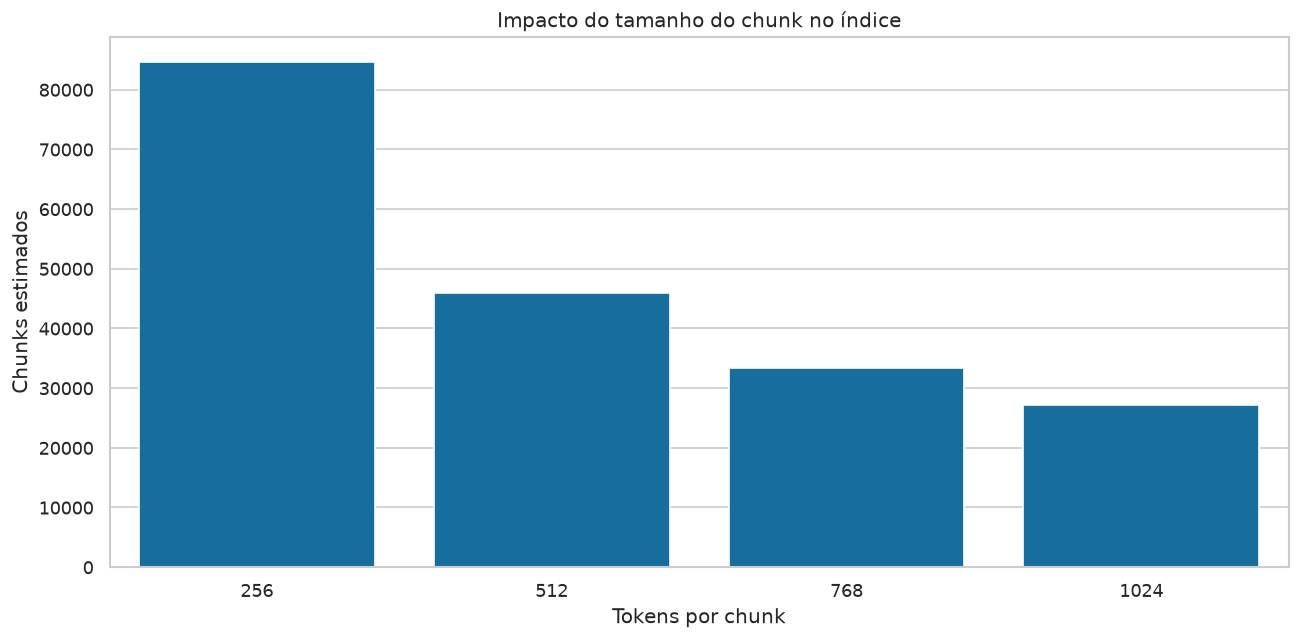

In [23]:
parametros = []
for tamanho in [256, 512, 768, 1024]:
    sobreposicao = tamanho // 8
    passo = tamanho - sobreposicao
    chunks = np.where(df['tokens_estimados'].eq(0), 0, np.maximum(1, np.ceil((df['tokens_estimados'] - sobreposicao) / passo)))
    parametros.append({
        'tamanho_chunk': tamanho, 'sobreposição': sobreposicao,
        'chunks_totais': int(chunks.sum()), 'chunks_por_documento': round(chunks.mean(), 2),
        'documentos_em_um_chunk_pct': round(100 * np.mean(chunks == 1), 2),
    })
comparacao_chunking = pd.DataFrame(parametros)
display(comparacao_chunking)
fig, ax = plt.subplots()
sns.barplot(data=comparacao_chunking, x='tamanho_chunk', y='chunks_totais', ax=ax)
ax.set(title='Impacto do tamanho do chunk no índice', xlabel='Tokens por chunk', ylabel='Chunks estimados')
plt.tight_layout()

## 8. Metadados e riscos para recuperação

Filtros por data, autor, partido, UF e tipo de uso podem elevar precisão e explicabilidade. A tabela mede a disponibilidade desses campos somente entre documentos indexáveis.

,campo,preenchidos,cobertura_pct,valores_unicos
3,Partido,13652,86.81,32
4,UF,13652,86.81,27
6,Indexacao,15666,99.62,10806
0,CodigoPronunciamento,15726,100.00,15726
2,NomeAutor,15726,100.00,1786
1,Data,15726,100.00,604
5,TipoUsoPalavra.Descricao,15726,100.00,22


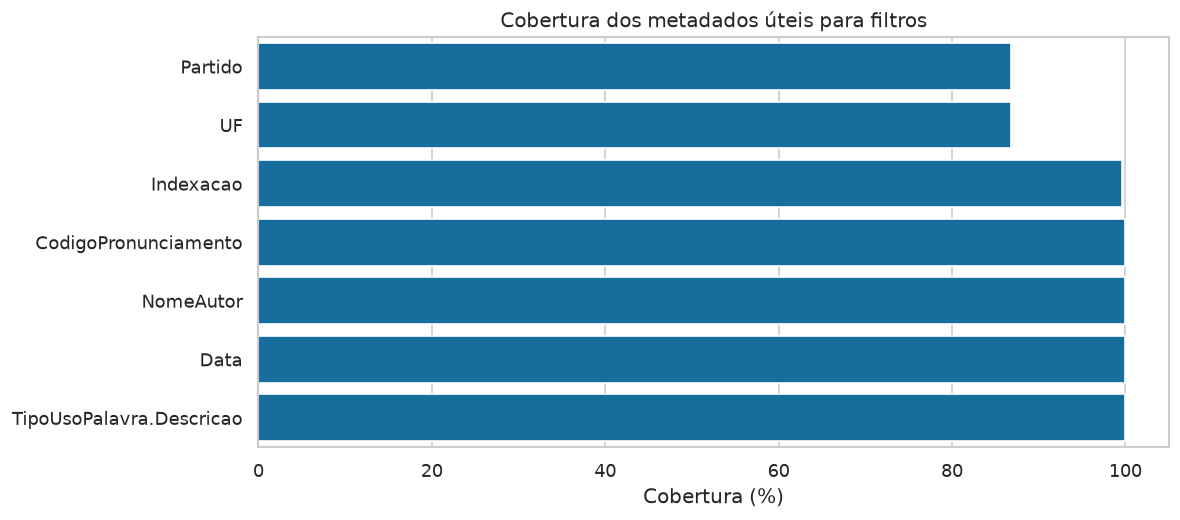

In [24]:
indexaveis = df[df['fonte_documento'].ne('indisponível')].copy()
campos_filtro = ['CodigoPronunciamento', 'Data', 'NomeAutor', 'Partido', 'UF', 'TipoUsoPalavra.Descricao', 'Indexacao']
cobertura_metadados = []
for coluna in campos_filtro:
    preenchido = indexaveis[coluna].notna() & indexaveis[coluna].astype(str).str.strip().ne('')
    cobertura_metadados.append({
        'campo': coluna, 'preenchidos': int(preenchido.sum()),
        'cobertura_pct': round(100 * preenchido.mean(), 2),
        'valores_unicos': indexaveis.loc[preenchido, coluna].nunique(),
    })
cobertura_metadados = pd.DataFrame(cobertura_metadados).sort_values('cobertura_pct')
display(cobertura_metadados)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=cobertura_metadados, x='cobertura_pct', y='campo', ax=ax)
ax.set(xlim=(0, 105), title='Cobertura dos metadados úteis para filtros', xlabel='Cobertura (%)', ylabel='')
plt.tight_layout()

In [25]:
def medir_concentracao(serie: pd.Series) -> dict[str, float]:
    proporcoes = serie.value_counts(normalize=True)
    return {
        'participação_top_1_pct': 100 * proporcoes.iloc[0],
        'participação_top_10_pct': 100 * proporcoes.iloc[:10].sum(),
        'HHI': float((proporcoes ** 2).sum()),
    }

# Análise principal: concentração somente entre valores conhecidos.
concentracao_conhecidos = {}
# Análise auxiliar: inclui a ausência como categoria explícita, sem confundi-la com representação real.
concentracao_com_ausencias = {}
for coluna in ['NomeAutor', 'Partido', 'UF']:
    conhecidos = indexaveis.loc[indexaveis[coluna].astype(str).str.strip().ne(''), coluna]
    com_ausencias = indexaveis[coluna].replace('', 'Não informado')
    concentracao_conhecidos[coluna] = medir_concentracao(conhecidos)
    concentracao_com_ausencias[coluna] = {
        **medir_concentracao(com_ausencias),
        'ausentes_pct': 100 * indexaveis[coluna].astype(str).str.strip().eq('').mean(),
    }

display(Markdown('### Concentração entre valores conhecidos'))
display(pd.DataFrame(concentracao_conhecidos).T.round(3))
display(Markdown('### Análise auxiliar incluindo ausências'))
display(pd.DataFrame(concentracao_com_ausencias).T.round(3))

### Concentração entre valores conhecidos

,participação_top_1_pct,participação_top_10_pct,HHI
NomeAutor,4.477,30.090,0.015
Partido,13.844,83.534,0.085
UF,8.263,54.783,0.046


### Análise auxiliar incluindo ausências

,participação_top_1_pct,participação_top_10_pct,HHI,ausentes_pct
NomeAutor,4.477,30.090,0.015,0.000
Partido,13.188,82.456,0.082,13.188
UF,13.188,57.160,0.052,13.188


## 9. Prontidão dos dados para experimentação com RAG

O quadro final consolida indicadores observáveis do corpus. Os limiares são heurísticos e servem para orientar o tratamento dos dados, não para certificar a qualidade de um sistema RAG. A construção de perguntas, julgamentos de relevância, chunks, embeddings e índices, assim como a avaliação da busca e das respostas, está deliberadamente fora do escopo deste notebook e será tratada no notebook 02.

In [26]:
pct_indexavel = 100 * indexaveis.shape[0] / len(df)
pct_integral = 100 * df['fonte_documento'].eq('texto_integral').mean()
pct_vazios = 100 * df['fonte_documento'].eq('indisponível').mean()
pct_copias = 100 * (grupos_duplicados - 1).sum() / len(df) if len(grupos_duplicados) else 0
pct_curto = 100 * df['n_palavras'].between(1, 49).mean()
cobertura_filtros = cobertura_metadados.set_index('campo')['cobertura_pct'].min()

scorecard = pd.DataFrame([
    ['Documentos indexáveis', pct_indexavel, '>= 99%', pct_indexavel >= 99],
    ['Cobertura de texto integral', pct_integral, '>= 90%', pct_integral >= 90],
    ['Registros sem conteúdo', pct_vazios, '< 1%', pct_vazios < 1],
    ['Cópias exatas excedentes', pct_copias, '< 2%', pct_copias < 2],
    ['Documentos com menos de 50 palavras', pct_curto, '< 10%', pct_curto < 10],
    ['Menor cobertura entre filtros', cobertura_filtros, '>= 90%', cobertura_filtros >= 90],
], columns=['indicador', 'valor_pct', 'referência', 'atende'])
scorecard['valor_pct'] = scorecard['valor_pct'].round(2)
scorecard['situação'] = scorecard['atende'].map({True: 'Adequado', False: 'Requer tratamento'})
display(scorecard.drop(columns='atende'))

,indicador,valor_pct,referência,situação
0,Documentos indexáveis,99.98,>= 99%,Adequado
1,Cobertura de texto integral,95.61,>= 90%,Adequado
2,Registros sem conteúdo,0.02,< 1%,Adequado
3,Cópias exatas excedentes,0.18,< 2%,Adequado
4,Documentos com menos de 50 palavras,8.21,< 10%,Adequado
5,Menor cobertura entre filtros,86.81,>= 90%,Requer tratamento


In [27]:
recomendacoes = [
    'Preservar CodigoPronunciamento, data, autor, partido, UF e proveniência em cada chunk.',
    'Indexar texto integral e resumo de fallback com marcadores distintos; não apresentá-los como equivalentes.',
    'Excluir da indexação os registros sem texto e sem resumo, mantendo-os no relatório de cobertura.',
    'Segmentar por parágrafos ou sentenças antes de aplicar limite de tokens e manter pequena sobreposição.',
    'Deduplicar apenas após inspeção: repetições podem ser registros legislativos legítimos.',
    'Combinar recuperação semântica com busca lexical e filtros de metadados.',
    'Criar um conjunto de avaliação estratificado por ano, partido, UF, tamanho e fonte do documento.',
    'Avaliar recuperação (Recall@k, MRR, nDCG), fidelidade da resposta e correção das citações separadamente.',
]
display(Markdown('### Recomendações para o pipeline\n' + '\n'.join(f'- {r}' for r in recomendacoes)))

### Recomendações para o pipeline
- Preservar CodigoPronunciamento, data, autor, partido, UF e proveniência em cada chunk.
- Indexar texto integral e resumo de fallback com marcadores distintos; não apresentá-los como equivalentes.
- Excluir da indexação os registros sem texto e sem resumo, mantendo-os no relatório de cobertura.
- Segmentar por parágrafos ou sentenças antes de aplicar limite de tokens e manter pequena sobreposição.
- Deduplicar apenas após inspeção: repetições podem ser registros legislativos legítimos.
- Combinar recuperação semântica com busca lexical e filtros de metadados.
- Criar um conjunto de avaliação estratificado por ano, partido, UF, tamanho e fonte do documento.
- Avaliar recuperação (Recall@k, MRR, nDCG), fidelidade da resposta e correção das citações separadamente.

## 10. Conclusão da análise exploratória

A caracterização e a auditoria de qualidade mostram que o corpus está, em termos gerais, apto a avançar para experimentos controlados de recuperação. O notebook cobre integridade do esquema, unicidade dos códigos, validade das datas, valores ausentes, cobertura do conteúdo, diferenciação entre texto integral e resumo, distribuições temporal, autoral, partidária e geográfica, tamanho dos documentos, casos curtos e longos, HTML, URLs, caracteres problemáticos, duplicidade exata e aproximada, frequência lexical, bigramas, mudança lexical anual, disponibilidade dos metadados, concentração de representação, estimativa de tokens e chunks, comparação de configurações de chunking e riscos para indexação.

### Resultados centrais para o futuro RAG

- **99,98%** dos registros são indexáveis;
- **95,61%** possuem texto integral;
- **687 registros** dependeriam de resumo como fallback;
- **3 registros** não possuem conteúdo textual utilizável;
- **8,21%** têm menos de 50 palavras;
- existem somente **28 cópias textuais exatas excedentes**;
- partido e UF apresentam cobertura de **86,81%**;
- chunks de 512 tokens e sobreposição de 64 tokens gerariam aproximadamente **45.971 chunks**;
- a mediana dos textos integrais seria de **dois chunks**;
- documentos extremos podem atingir aproximadamente **60 chunks**.

Esses resultados não medem a qualidade de um RAG. Eles estabelecem a prontidão dos dados, documentam limitações e fornecem parâmetros iniciais para os experimentos. Métricas de recuperação e de geração serão aplicadas separadamente no notebook 02.

## 11. Exportação opcional de artefatos

A exportação fica desativada por padrão. Quando habilitada, grava somente tabelas derivadas em `texto-Latex/dados/`; nunca modifica o corpus original. As figuras podem ser salvas seletivamente após definição do padrão visual da dissertação.

In [28]:
EXPORTAR = True
if EXPORTAR:
    raiz_dissertacao = next(
        p for p in [Path.cwd() / '13-dissertacao', Path.cwd().parent, Path.cwd()]
        if (p / 'texto-Latex').exists()
    )
    destino = raiz_dissertacao / 'texto-Latex' / 'dados'
    destino.mkdir(parents=True, exist_ok=True)
    visao_colunas.to_csv(destino / 'auditoria_colunas.csv', encoding='utf-8', index=True)
    cobertura.to_csv(destino / 'cobertura_textual.csv', encoding='utf-8', index=True)
    comparacao_chunking.to_csv(destino / 'estimativa_chunking.csv', encoding='utf-8', index=False)
    scorecard.drop(columns='atende').to_csv(destino / 'prontidao_dados_experimentacao_rag.csv', encoding='utf-8', index=False)
    print(f'Artefatos exportados para {destino}')
else:
    print('Exportação desativada; nenhum arquivo foi criado.')

Artefatos exportados para /workspaces/mcdia/13-dissertacao/texto-Latex/dados


## 12. Próximos passos: notebook 02

A avaliação empírica da recuperação e da geração está fora do escopo desta análise exploratória. Ela será desenvolvida em `02-avaliar-recuperacao-rag.ipynb`, contemplando:

1. construção de um conjunto de perguntas estratificado;
2. indicação dos pronunciamentos relevantes para cada pergunta;
3. criação efetiva dos chunks;
4. comparação de tamanhos e sobreposições;
5. comparação entre BM25, busca vetorial e busca híbrida;
6. cálculo de Recall@1, Recall@5, Recall@10, MRR e nDCG@k;
7. análise por ano, partido, tamanho do documento e tipo de fonte;
8. avaliação da diversidade dos resultados;
9. análise manual dos erros;
10. avaliação posterior das respostas geradas, separada da recuperação, incluindo fidelidade, groundedness e correção das citações.

Esse desenho separa a qualidade do corpus, a qualidade da recuperação e a qualidade da resposta gerada, evitando atribuir ao modelo generativo problemas originados na indexação ou na busca.